# Problem Statement 4: - 
A Mobile Phone manufacturing company wants to launch its three brand new phone into the market, but before going with its traditional marketing approach this time it want to analyze the data of its previous model sales in different regions and you have been hired as an Data Scientist to help them out, use the Association rules concept and provide your insights to the company’s marketing team to improve its sales.
4.) myphonedata.csv


Business Objective:

The primary objective of the mobile phone manufacturing company is to enhance the effectiveness of its marketing strategy for the launch of three new phone models

In [14]:
#import reuired libraries
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("F:/Data science/Assignments/PCA assignment/myphonedata.csv")

C:\Users\Sai\anaconda3\lib\site-packages\seaborn\rcmod.py:82: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":
C:\Users\Sai\anaconda3\lib\site-packages\setuptools\_distutils\version.py:346: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


In [15]:
# Dataset Exploration and Data Dictionary
df.head(5)

,red,white,green,yellow,orange,blue
0,1,1,1,0,0,0
1,0,1,0,0,1,0
2,0,1,0,0,0,1
3,1,1,0,0,1,0
4,1,0,0,0,0,1


In [16]:
#shape
df.shape

(11, 6)

In [17]:
#describe dataset
df.describe()

,red,white,green,yellow,orange,blue
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,0.545455,0.636364,0.181818,0.090909,0.181818,0.545455
std,0.522233,0.504525,0.404520,0.301511,0.404520,0.522233
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
# Data Pre-processing
#Check for missing values
df.isnull().sum()

red       0
white     0
green     0
yellow    0
orange    0
blue      0
dtype: int64

In [19]:
#fill the missing values
df.fillna(0, inplace=True)

In [20]:
#Confirm that missing values are handled
print("\nAfter filling missing values:")
print(df.isnull().sum())


After filling missing values:
red       0
white     0
green     0
yellow    0
orange    0
blue      0
dtype: int64


In [21]:
#import necessary libraries to apply association rule
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [22]:
# Apply the Apriori algorithm
frequent_itemsets = apriori(df, min_support=0.1, use_colnames=True)  # Adjust min_support as needed
print(frequent_itemsets)

    support            itemsets
0  0.545455               (red)
1  0.636364             (white)
2  0.181818             (green)
3  0.181818            (orange)
4  0.545455              (blue)
5  0.363636        (white, red)
6  0.363636         (red, blue)
7  0.181818     (orange, white)
8  0.363636       (white, blue)
9  0.181818  (white, red, blue)


C:\Users\Sai\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [23]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

  antecedents consequents   support  confidence      lift
0     (white)       (red)  0.363636    0.571429  1.047619
1       (red)     (white)  0.363636    0.666667  1.047619
2       (red)      (blue)  0.363636    0.666667  1.222222
3      (blue)       (red)  0.363636    0.666667  1.222222
4    (orange)     (white)  0.181818    1.000000  1.571429
5     (white)    (orange)  0.181818    0.285714  1.571429
6     (white)      (blue)  0.363636    0.571429  1.047619
7      (blue)     (white)  0.363636    0.666667  1.047619


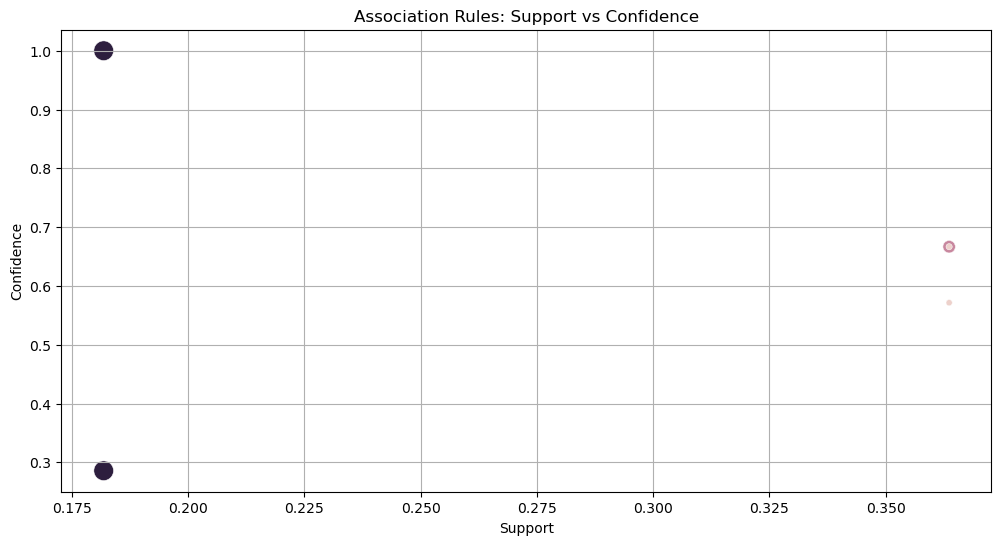

In [24]:
# Plot the results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', sizes=(20, 200), hue='lift', legend=False)
plt.title('Association Rules: Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid()
plt.show()

# Problem Statement 5: - 
A retail store in India, has its transaction data, and it would like to know the buying pattern of the 
consumers in its locality, you have been assigned this task to provide the manager with rules
on how the placement of products needs to be there in shelves so that it can improve the buying
patterns of consumes and increase customer footfall. 
5.) transaction_retail.csv


Business Objective:

The primary objective of the retail store is to enhance customer buying patterns and increase footfall by analyzing transaction data. 

In [26]:
#import reuired libraries
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

In [27]:
data = {
    'Item1': ['LANTERN', 'COAT', 'BOTTLE', 'HEART.', '7'],
    'Item2': ['METAL', 'CREAM', 'FLAG', 'HOTTIE', 'BABUSHKA'],
    'Item3': ['WHITE', 'CUPID', 'HOT', 'RED', 'BOXES'],
    'Item4': [None, 'HANGER', 'KNITTED', 'WHITE', 'NESTING'],
    'Item5': [None, 'HEARTS', 'UNION', 'WOOLLY', 'SET'],
    'Item6': [None, None, 'WATER', None, None]
}

In [28]:
# Convert to DataFrame
df = pd.DataFrame(data)

In [29]:
# Convert the transactional data into binary encoding (One-Hot Encoding)
df_binary = pd.get_dummies(df.stack()).groupby(level=0).sum()
df_binary = df_binary.applymap(lambda x: 1 if x > 0 else 0)

In [30]:
# Check the processed data
print(df_binary.head())

   7  BABUSHKA  BOTTLE  BOXES  COAT  CREAM  CUPID  FLAG  HANGER  HEART.  ...  \
0  0         0       0      0     0      0      0     0       0       0  ...   
1  0         0       0      0     1      1      1     0       1       0  ...   
2  0         0       1      0     0      0      0     1       0       0  ...   
3  0         0       0      0     0      0      0     0       0       1  ...   
4  1         1       0      1     0      0      0     0       0       0  ...   

   KNITTED  LANTERN  METAL  NESTING  RED  SET  UNION  WATER  WHITE  WOOLLY  
0        0        1      1        0    0    0      0      0      1       0  
1        0        0      0        0    0    0      0      0      0       0  
2        1        0      0        0    0    0      1      1      0       0  
3        0        0      0        0    1    0      0      0      1       1  
4        0        0      0        1    0    1      0      0      0       0  

[5 rows x 23 columns]


In [31]:
# Applying the Apriori algorithm
frequent_itemsets = apriori(df_binary, min_support=0.1, use_colnames=True)

C:\Users\Sai\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [32]:
# Display frequent itemsets
print(frequent_itemsets)

     support                                    itemsets
0        0.2                                         (7)
1        0.2                                  (BABUSHKA)
2        0.2                                    (BOTTLE)
3        0.2                                     (BOXES)
4        0.2                                      (COAT)
..       ...                                         ...
157      0.2        (HOT, BOTTLE, WATER, KNITTED, UNION)
158      0.2        (COAT, HEARTS, HANGER, CUPID, CREAM)
159      0.2          (HOT, WATER, KNITTED, UNION, FLAG)
160      0.2        (WOOLLY, HOTTIE, HEART., WHITE, RED)
161      0.2  (HOT, BOTTLE, WATER, KNITTED, UNION, FLAG)

[162 rows x 2 columns]


In [33]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

In [34]:
# Display the association rules
print(rules)

     antecedents                           consequents  antecedent support  \
0     (BABUSHKA)                                   (7)                 0.2   
1            (7)                            (BABUSHKA)                 0.2   
2            (7)                               (BOXES)                 0.2   
3        (BOXES)                                   (7)                 0.2   
4      (NESTING)                                   (7)                 0.2   
...          ...                                   ...                 ...   
1149    (BOTTLE)    (HOT, WATER, KNITTED, UNION, FLAG)                 0.2   
1150     (WATER)   (HOT, BOTTLE, KNITTED, UNION, FLAG)                 0.2   
1151   (KNITTED)     (HOT, BOTTLE, WATER, UNION, FLAG)                 0.2   
1152     (UNION)   (HOT, BOTTLE, WATER, KNITTED, FLAG)                 0.2   
1153      (FLAG)  (HOT, BOTTLE, WATER, KNITTED, UNION)                 0.2   

      consequent support  support  confidence  lift  leverage  